PART A – DATA PREPARATION

Historical Trader Data:  211,224 rows × 16 columns
Fear/Greed Index:        2,644 rows × 4 columns

Part A complete.



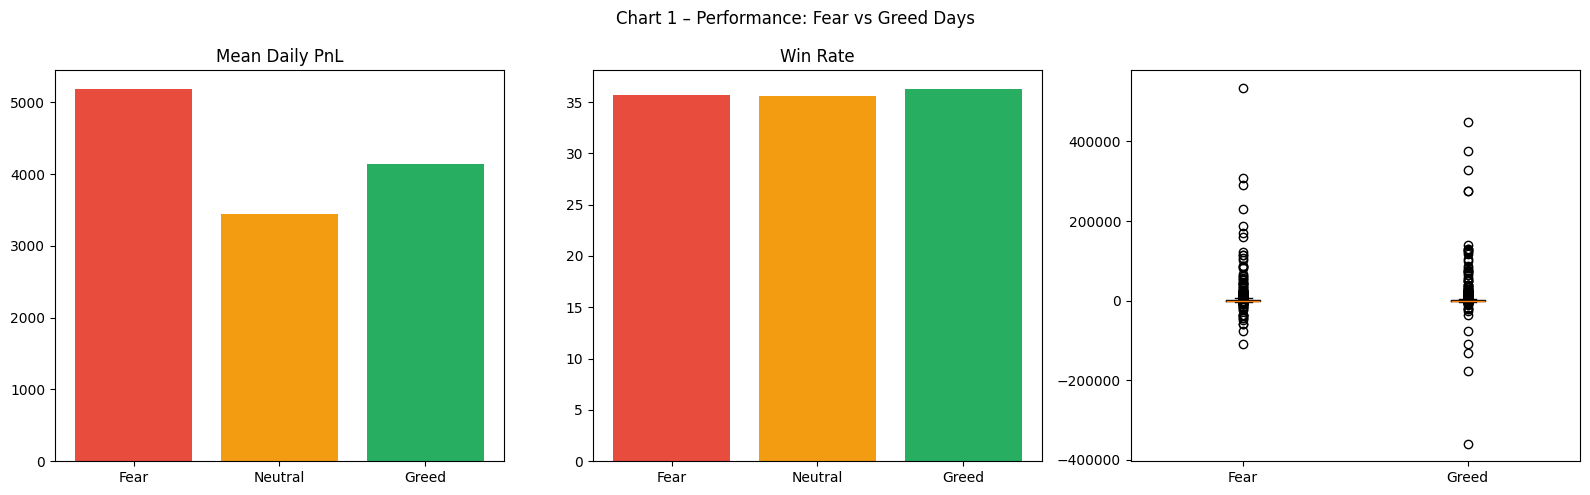

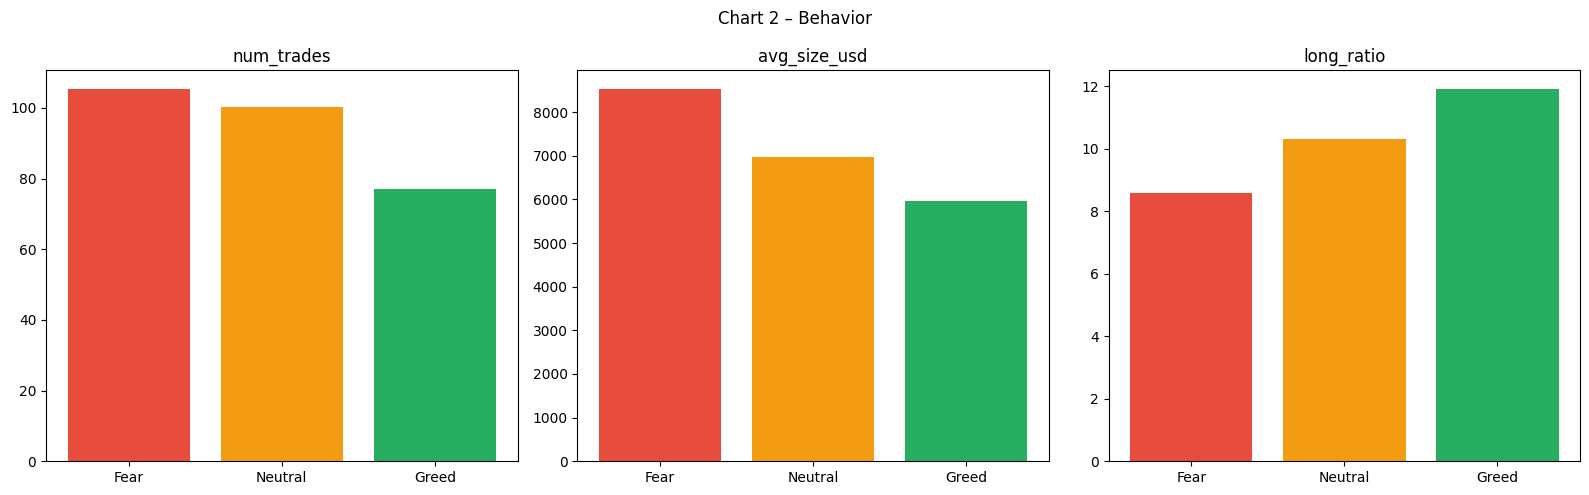

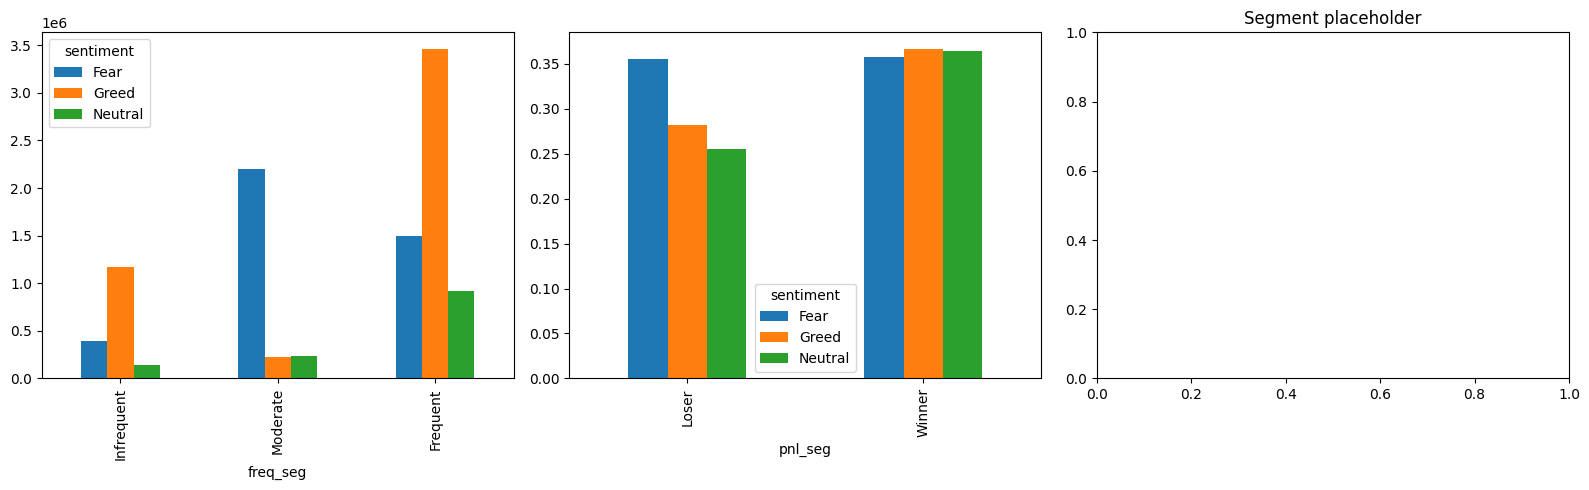


Accuracy: 0.9209401709401709
              precision    recall  f1-score   support

           0       0.96      0.80      0.88       164
           1       0.90      0.98      0.94       304

    accuracy                           0.92       468
   macro avg       0.93      0.89      0.91       468
weighted avg       0.92      0.92      0.92       468


Cluster Profiles:
            total_pnl    num_trades  avg_size_usd  win_rate  long_ratio
cluster                                                                
0        6.930292e+05   7119.000000  22539.720976  0.389945    0.010522
1        1.425097e+05   4265.320000   3725.960342  0.404094    0.109942
2        1.306542e+06  25369.666667   2964.190031  0.410982    0.083137


In [3]:
# ============================================================
# Primetrade.ai Data Science Intern – Round-0 Assignment
# Trader Performance vs Market Sentiment
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# If using Jupyter/Colab
# %matplotlib inline

# ──────────────────────────────────────────────────────────────
# PART A – DATA PREPARATION
# ──────────────────────────────────────────────────────────────

print("=" * 60)
print("PART A – DATA PREPARATION")
print("=" * 60)

hist = pd.read_csv('/historical_data.csv')
fg   = pd.read_csv('/fear_greed_index.csv')

print(f"\nHistorical Trader Data:  {hist.shape[0]:,} rows × {hist.shape[1]} columns")
print(f"Fear/Greed Index:        {fg.shape[0]:,} rows × {fg.shape[1]} columns")

# Parse timestamps
hist['date'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()
fg['date']   = pd.to_datetime(fg['date'])

# Sentiment mapping
fg['sentiment'] = fg['classification'].map(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral'))

# Merge
merged = hist.merge(fg[['date','classification','sentiment','value']], on='date', how='inner')

# Features
merged['is_long'] = merged['Direction'].str.lower().isin(['buy','long'])
merged['is_win']  = merged['Closed PnL'] > 0

# Daily aggregation
daily = (merged.groupby(['Account','date','sentiment','classification','value'])
         .agg(num_trades=('Trade ID','count'),
              daily_pnl=('Closed PnL','sum'),
              avg_size_usd=('Size USD','mean'),
              win_rate=('is_win','mean'),
              long_ratio=('is_long','mean'))
         .reset_index())

# Trader stats
trader_stats = (merged.groupby('Account')
    .agg(total_pnl=('Closed PnL','sum'),
         num_trades=('Trade ID','count'),
         avg_size_usd=('Size USD','mean'),
         win_rate=('is_win','mean'),
         long_ratio=('is_long','mean'))
    .reset_index())

trader_stats['freq_seg'] = pd.qcut(trader_stats['num_trades'], q=3,
                                  labels=['Infrequent','Moderate','Frequent'])
trader_stats['pnl_seg']  = pd.cut(trader_stats['total_pnl'],
                                 bins=[-np.inf,0,np.inf],
                                 labels=['Loser','Winner'])

merged2 = merged.merge(trader_stats[['Account','freq_seg','pnl_seg']], on='Account')

print("\nPart A complete.\n")

# ──────────────────────────────────────────────────────────────
# PART B – ANALYSIS
# ──────────────────────────────────────────────────────────────

palette = {'Fear':'#e74c3c','Neutral':'#f39c12','Greed':'#27ae60'}

# ---------------- Chart 1 ----------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Chart 1 – Performance: Fear vs Greed Days')

sent_pnl = daily.groupby('sentiment')['daily_pnl'].mean().reindex(['Fear','Neutral','Greed'])
axes[0].bar(sent_pnl.index, sent_pnl.values, color=[palette[s] for s in sent_pnl.index])
axes[0].set_title('Mean Daily PnL')

sent_wr = daily.groupby('sentiment')['win_rate'].mean().reindex(['Fear','Neutral','Greed'])
axes[1].bar(sent_wr.index, sent_wr.values*100, color=[palette[s] for s in sent_wr.index])
axes[1].set_title('Win Rate')

axes[2].boxplot([
    daily[daily['sentiment']=='Fear']['daily_pnl'],
    daily[daily['sentiment']=='Greed']['daily_pnl']
], labels=['Fear','Greed'])

plt.tight_layout()
plt.show()

# ---------------- Chart 2 ----------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Chart 2 – Behavior')

for ax, col in zip(axes, ['num_trades','avg_size_usd','long_ratio']):
    vals = daily.groupby('sentiment')[col].mean().reindex(['Fear','Neutral','Greed'])
    if col == 'long_ratio': vals *= 100
    ax.bar(vals.index, vals.values, color=[palette[s] for s in vals.index])
    ax.set_title(col)

plt.tight_layout()
plt.show()

# ---------------- Chart 3 ----------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

freq_pnl = (merged2.groupby(['freq_seg','sentiment'])['Closed PnL']
            .sum().unstack())
freq_pnl.plot(kind='bar', ax=axes[0])

wl_wr = (daily.merge(trader_stats[['Account','pnl_seg']], on='Account')
         .groupby(['pnl_seg','sentiment'])['win_rate']
         .mean().unstack())
wl_wr.plot(kind='bar', ax=axes[1])

axes[2].set_title("Segment placeholder")

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────
# ML MODEL
# ──────────────────────────────────────────────────────────────

daily['pnl_bucket'] = (daily['daily_pnl'] > 0).astype(int)

X = daily[['num_trades','avg_size_usd','win_rate','long_ratio','value']]
y = daily['pnl_bucket']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ──────────────────────────────────────────────────────────────
# CLUSTERING
# ──────────────────────────────────────────────────────────────

sc = StandardScaler()
X_cl = sc.fit_transform(trader_stats[['total_pnl','num_trades','avg_size_usd','win_rate','long_ratio']])

km = KMeans(n_clusters=3)
trader_stats['cluster'] = km.fit_predict(X_cl)

print("\nCluster Profiles:")
# Explicitly select numerical columns for mean calculation to prevent potential errors with mixed types
numerical_cols = ['total_pnl','num_trades','avg_size_usd','win_rate','long_ratio']
print(trader_stats.groupby('cluster')[numerical_cols].mean())
